*Alunos: Bruno Calabria Cortez Navas // Eduardo Brioso Luceiro*

In [48]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# Leitura e exibição do banco de dados

file = pd.read_csv("./VG_Sales.csv")
file = file.dropna() # Remoção de lihas com dados vazios
file

,Name,Console,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
7,Wii Play,Wii,2006.0,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16667,E.T. The Extra-Terrestrial,GBA,2001.0,Action,NewKidCo,0.01,0.00,0.00,0.00,0.01,46.0,4.0,2.4,21.0,Fluid Studios,E
16677,Mortal Kombat: Deadly Alliance,GBA,2002.0,Fighting,Midway Games,0.01,0.00,0.00,0.00,0.01,81.0,12.0,8.8,9.0,Criterion Games,M
16696,Metal Gear Solid V: Ground Zeroes,PC,2014.0,Action,Konami Digital Entertainment,0.00,0.01,0.00,0.00,0.01,80.0,20.0,7.6,412.0,Kojima Productions,M
16700,Breach,PC,2011.0,Shooter,Destineer,0.01,0.00,0.00,0.00,0.01,61.0,12.0,5.8,43.0,Atomic Games,T


## Estimação de parâmetros
Nesta seção, calcularemos a média geral de notas de usuário e a média geral de notas de empresas a fim de verificar se são similares.

In [34]:
# Transforma o campo User_Score do CSV em dados numéricos
file['User_Score'] = pd.to_numeric(file['User_Score'], errors='coerce')
file.dropna(subset=['User_Score'], inplace=True)

# Média e desvio padrão das notas de usuários
mean_userScore = file['User_Score'].mean()
std_userScore = file['User_Score'].std()
n_userScore = file['User_Score'].count()

print(f"Nota média de usuários: {mean_userScore:.2f}")
print(f"Desvio padrão de notas de usuários: {std_userScore:.2f}")

# Utilizando um intervalo de confiança de 95%
# Como o desvio padrão da população é desconhecido, podemos usar distribuição t para calcular a média neste intervalo de confiança
confianca = 0.95
liberdade = n_userScore - 1
erro = std_userScore / np.sqrt(n_userScore)

intervaloConfianca = stats.t.interval(confianca, liberdade,
                                       loc=mean_userScore,
                                       scale=erro)

print(f"Intervalo de confiança de 95% para nota de usuários: ({intervaloConfianca[0]:.2f}, {intervaloConfianca[1]:.2f})")

Nota média de usuários: 7.19
Desvio padrão de notas de usuários: 1.44
Intervalo de confiança de 95% para nota de usuários: (7.15, 7.22)


In [35]:
# Transforma o campo Critic_Score do CSV em dados numéricos
file['Critic_Score'] = pd.to_numeric(file['Critic_Score'], errors='coerce')
file.dropna(subset=['Critic_Score'], inplace=True)

# As notas da crítica podem ser dadas de 0 a 100, enquanto as de usuário vão de 0 a 10. Por isso, vamos ajustar os dados na hora de mostrá-los.

# Média e desvio padrão das notas de crítica
mediacriticScore = file['Critic_Score'].mean()
desvpdcriticScore = file['Critic_Score'].std()
ncriticScore = file['Critic_Score'].count()

mean_criticScoreN = mediacriticScore/10
std_criticScoreN = desvpdcriticScore/10
print(f"Nota média da crítica: {mean_criticScoreN:.2f}")
print(f"Desvio padrão de notas de crítica: {std_criticScoreN:.2f}")

# Utilizando um intervalo de confiança de 95%
# Como o desvio padrão da população é desconhecido, podemos usar distribuição t para calcular a média neste intervalo de confiança
confianca = 0.95
liberdade = ncriticScore - 1
erro = desvpdcriticScore / np.sqrt(ncriticScore)

intervaloConfianca = stats.t.interval(confianca, liberdade,
                                       loc=mediacriticScore,
                                       scale=erro)

intervaloConfianca0N = intervaloConfianca[0]/10
intervaloConfianca1N = intervaloConfianca[1]/10
print(f"Intervalo de confiança de 95% para nota da crítica: ({intervaloConfianca0N:.2f}, {intervaloConfianca1N:.2f})")

Nota média da crítica: 7.03
Desvio padrão de notas de crítica: 1.39
Intervalo de confiança de 95% para nota da crítica: (6.99, 7.06)


## Teste de hipóteses
A seguir, testaremos duas hipóteses:
1. O número de vendas médio por gênero apresenta diferença de até 10% entre diferentes gêneros
2. Existe uma diferença de mais de 10% entre as notas médias de usuários em diferentes.

In [36]:
# Obter o número de vendas por gênero
sportsVendas = file[file['Genre']=='Sports']['Global_Sales']
actionVendas = file[file['Genre']=='Action']['Global_Sales']
platformVendas = file[file['Genre']=='Platform']['Global_Sales']
rpgVendas = file[file['Genre']=='Role-Playing']['Global_Sales']
racingVendas = file[file['Genre']=='Racing']['Global_Sales']
puzzleVendas = file[file['Genre']=='Puzzle']['Global_Sales']

# Obter a média do número de vendas de cada gênero
mediaSports = sportsVendas.mean()
mediaAction = actionVendas.mean()
mediaPlatform = platformVendas.mean()
mediaRPG = rpgVendas.mean()
mediaRacing = racingVendas.mean()
mediaPuzzle = puzzleVendas.mean()

# Mostrar os resultados
print(f"--- Número de Vendas Médio por Gênero (milhões de unidades) ---\n Esportes: {mediaSports:.3f} \n Ação: {mediaAction:.3f} \n Plataforma: {mediaPlatform:.3f} \n RPG: {mediaRPG:.3f} \n Corrida: {mediaRacing:.3f} \n Quebra-cabeça: {mediaPuzzle:.3f}")

--- Número de Vendas Médio por Gênero (milhões de unidades) ---
 Esportes: 0.884 
 Ação: 0.738 
 Plataforma: 0.937 
 RPG: 0.704 
 Corrida: 0.820 
 Quebra-cabeça: 0.669


Vê-se que a hipótese inicial estava errada, tendo em vista que, por exemplo, há uma diferença de 40% entre o número de vendas de jogos de quebra-cabeça e o de jogos de plataforma. Portanto, vale a hipótese complementar de que a diferença entre o número médio de vendas de diferentes gêneros pode ser maior que 10%.

In [37]:
# Obter as notas de usuário por empresa
nintendoVendas = file[file['Publisher']=='Nintendo']['User_Score']
microsoftVendas = file[file['Publisher']=='Microsoft Game Studios']['User_Score']
taketwoVendas = file[file['Publisher']=='Take-Two Interactive']['User_Score']
activisionVendas = file[file['Publisher']=='Activision']['User_Score']
sonyVendas = file[file['Publisher']=='Sony Computer Entertainment']['User_Score']
ubisoftVendas = file[file['Publisher']=='Ubisoft']['User_Score']
eavendas = file[file['Publisher']=='Electronic Arts']['User_Score']

# Obter as médias das notas de usuário para cada empresa
mediaNintendo = nintendoVendas.mean()
mediaMicrosoft = microsoftVendas.mean()
mediaTakeTwo = taketwoVendas.mean()
mediaActivision = activisionVendas.mean()
mediaSony = sonyVendas.mean()
mediaUbisoft= ubisoftVendas.mean()
mediaEA = eavendas.mean()

# Mostrar os resultados
print(f"--- Nota média de usuários por empresa ---\n Nintendo: {mediaNintendo:.3f} \n Microsoft Game Studios: {mediaMicrosoft:.3f} \n Take-Two Interactive: {mediaTakeTwo:.3f} \n Activision: {mediaActivision:.3f} \n Sony Computer Entertainment: {mediaSony:.3f} \n Ubisoft: {mediaUbisoft:.3f}\n Electronic Arts: {mediaEA:.3f}")

--- Nota média de usuários por empresa ---
 Nintendo: 7.923 
 Microsoft Game Studios: 7.428 
 Take-Two Interactive: 7.163 
 Activision: 6.885 
 Sony Computer Entertainment: 7.633 
 Ubisoft: 7.062
 Electronic Arts: 7.138


Neste caso, a hipótese inicial estava certa. Pode-se verificar isso ao compararmos os extremos das notas: a Nintendo apresenta média 7.923, enquanto a Activision tem média 6.885, o que significa uma diferença de 15%. Desse modo, dentre as empresas analisadas, a diferença de média de notas de usuários extrapola 10%.

## Regressão linear
Aqui, verificaremos se é possível prever as vendas globais com base em vendas de determinada região.

In [38]:
# Variável independente: Vendas na América do Norte
# Variável dependente: Vendas Globais
X = file['NA_Sales']
y = file['Global_Sales']

# Adiciona uma constante à variável dependente 
X = sm.add_constant(X)

# Cria e aplica o modelo OLS (Ordinary Leas Squares ou Modelo dos Mínimos Quadrados)
model = sm.OLS(y, X)
resultados = model.fit()

print(f"\n--- Regressão Linear Vendas América do Norte vs Vendas Globais ---")
print(resultados.summary())

# Interpretação
print(f"\n Equação: Vendas Globais = {resultados.params['const']:.2f} + {resultados.params['NA_Sales']:.2f} * Vendas AN")
print(f"R-squared: {resultados.rsquared:.3f}")
print(f"P: {resultados.pvalues['NA_Sales']:.3e}")


--- Regressão Linear Vendas América do Norte vs Vendas Globais ---
                            OLS Regression Results                            
Dep. Variable:           Global_Sales   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.914
Method:                 Least Squares   F-statistic:                 7.209e+04
Date:                Wed, 11 Jun 2025   Prob (F-statistic):               0.00
Time:                        22:14:16   Log-Likelihood:                -5934.5
No. Observations:                6825   AIC:                         1.187e+04
Df Residuals:                    6823   BIC:                         1.189e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

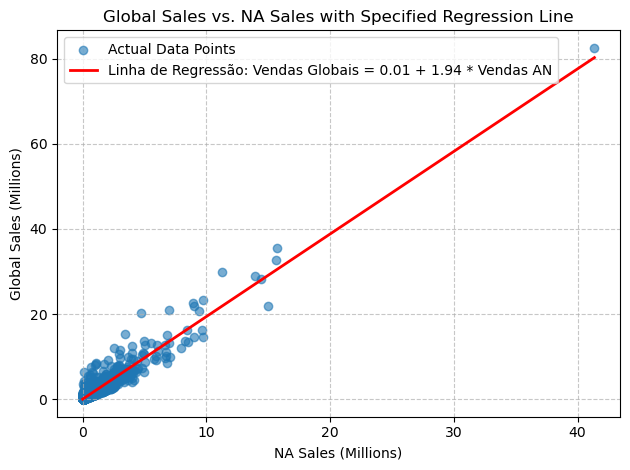

In [49]:
plt.scatter(x='NA_Sales', y='Global_Sales', data=file, alpha=0.6, label='Actual Data Points')

intercept = 0.01
inclinacao = 1.94

escopoVendasNA = np.linspace(file['NA_Sales'].min(), file['NA_Sales'].max(), 100)
regressao = intercept + inclinacao * escopoVendasNA

plt.plot(escopoVendasNA, regressao, color='red', linewidth=2, label=f'Linha de Regressão: Vendas Globais = {intercept} + {inclinacao} * Vendas AN')

plt.title('Vendas Globais vs. Vendas AN com Linha de Regressão Linear')
plt.xlabel('Vendas AN (milhões de cópias)')
plt.ylabel('Vendas Globais (milhões de cópias)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Ou seja, a relação entre vendas globais e vendas na América do Norte pode ser expressa pela equação $\text{Vendas Globais}=0.01+1.94*\text{Vendas América do norte}$ e tem gráfico conforme o visto acima.

## ANOVA
Com este método, faremos as seguintes comparações:
1. Quantidade de vendas entre empresas
2. Quantidade de vendas entre gêneros

In [40]:
# Vetor de empresas que constarão na comparação
empresasComparacao = ['Nintendo', 'Microsoft Game Studios', 'Take-Two Interactive', 'Activision', 'Sony Computer Entertainment', 'Ubisoft', 'Electronic Arts']

# Filtrar o dataframe por empresa
dfFiltrado = file[file['Publisher'].isin(empresasComparacao)]

# Obter o número de vendas por empresa para cada empresa no vetor definido
vendasEmpresas = [dfFiltrado[dfFiltrado['Publisher']==empresa]['Global_Sales'] for empresa in empresasComparacao]

# Aplicar o método ANOVA
f, p = stats.f_oneway(*vendasEmpresas)

# Mostrar resultados
print(f"---ANOVA Vendas Globais por Empresa---")
print(f"Estatística F: {f:.3f}")
print(f"p: {p:.3e}")


---ANOVA Vendas Globais por Empresa---
Estatística F: 24.110
p: 5.293e-28


Considerando nível de significância 0.05, como $p\lt\lt0.05$, percebe-se que a empresa que publica o jogo tem impacto significativo no seu desempenho comercial. Chegamos à essa conclusão na primeira parte do trabalho e podemos ver que, mesmo utilizando outros métodos, ela se mantém.

In [41]:
# Vetor de gêneros que constarão na comparação 
generoComparacao = ['Sports', 'Action', 'Role-Playing', 'Racing', 'Platform', 'Puzzle']

# Filtrar o dataframe por empresa
dfFiltrado = file[file['Genre'].isin(generoComparacao)]

# Obter o número de vendas para cada gênero no vetor definido
vendasGenero = [dfFiltrado[dfFiltrado['Genre']==genero]['Global_Sales'] for genero in generoComparacao]

# Aplicar o método ANOVA
f, p = stats.f_oneway(*vendasGenero)

# Mostrar resultados 
print(f"---ANOVA Vendas globais por gênero---")
print(f"Estatística F: {f:.3f}")
print(f"p: {p:.3e}")


---ANOVA Vendas globais por gênero---
Estatística F: 1.290
p: 2.650e-01


Considerando nível de significância 0.05, vê-se que, como $p>0.05$, então o gênero do jogo não tem impacto significativo no seu número de vendas.

## Qui-quadrado
Por fim, tentaremos responder as seguintes perguntas:
1. O gênero é independente da classificação etária do jogo?
2. Qual a relação entre o período de tempo e o número de vendas?

In [42]:
# Criar a tabela de contingência
tabela = pd.crosstab(file['Genre'], file['Rating'])

# Aplicar o método qui-quadrado e obter os parâmetros de análise
chi2, p, liberdade, esperado = stats.chi2_contingency(tabela)

# Mostrar os resultados
print(f"\n--- Teste de independência Qui-Quadrado (Gênero vs Classificação etária) ---")
print(f"Estatística qui-quadrado: {chi2:.3f}")
print(f"P: {p:.3e}")
print(f"Graus de liberdade: {liberdade}")


--- Teste de independência Qui-Quadrado (Gênero vs Classificação etária) ---
Estatística qui-quadrado: 3993.758
P: 0.000e+00
Graus de liberdade: 66


In [43]:
# Criar a tabela de contingência
tabela = pd.crosstab(file['Year_of_Release'], file['Global_Sales'])

# Aplicar o método qui-quadrado e obter os parâmetros de análise
chi2, p, liberdade, esperado = stats.chi2_contingency(tabela)

# Mostrar os resultados
print(f"\n--- Teste de independência Qui-Quadrado (Ano de lançamento vs Vendas Globais) ---")
print(f"Estatística qui-quadrado: {chi2:.3f}")
print(f"P: {p:.3e}")
print(f"Graus de liberdade: {liberdade}")


--- Teste de independência Qui-Quadrado (Ano de lançamento vs Vendas Globais) ---
Estatística qui-quadrado: 17814.707
P: 7.518e-170
Graus de liberdade: 12840


Sendo o nível de significância 0.05, nota-se que $p<0.05$. Por isso, as variáveis possuem uma associação estatisticamente significativa.